# 01 · Exploratory analysis and data-quality audit

**Business question:** classify TV shows into *Comedy*, *Drama* or *Reality* from features supplied by several business units. Marketing campaigns depend on the segmentation, so accuracy is critical.

The inputs are **raw, unmastered and unvalidated**. Before any modelling, this notebook audits the data and builds the evidence for each cleaning rule:

| Finding | Evidence | Action |
|---|---|---|
| D, F, K are copies of I | identical values wherever present | keep I (complete), drop the copies |
| ~5% of A values are 100x too large | empty gap between abs(A) 5.2 and 12.2; rescaled values match (KS test); regression on other features gives a ratio of ~100 | divide by 100, flag |
| J is missing for 7% of shows | J is an exact linear combination of B, C, I, L, M, N | reconstruct J exactly |
| E, H, O carry no genre signal | Kruskal-Wallis FDR q > 0.05, mutual information ~0 | candidates for removal |

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
from src.data import make_dataset
from src.data.make_dataset import load_raw, audit, main as make_data
tr, te = load_raw()
display(tr.head())
print("training:", tr.shape, "| test:", te.shape)

13:21:13 | INFO    | src.data.make_dataset | Loaded raw training (600, 16) and test (400, 16)


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,genre
0,0.626497,2.685548,1.010340,-1.520117,0.597521,-1.520117,0.939595,-1.773054,-1.520117,-0.962927,-1.520117,-3.279177,2.500132,0.371823,0.066263,Comedy
1,1.092415,3.306759,3.630600,0.701183,-0.464522,0.701183,0.987897,-0.900386,0.701183,2.638210,0.701183,3.121688,0.025020,-1.674695,1.283004,Reality
2,1.770764,1.673773,-0.488041,0.254061,-0.234522,0.254061,-1.879444,-0.499966,0.254061,0.447729,0.254061,-0.966404,1.899810,0.603490,0.784307,Reality
3,-0.227963,-0.635166,1.056773,-1.141062,-0.051091,-1.141062,-0.655769,-0.241350,-1.141062,-0.956955,-1.141062,0.156783,-1.121375,-0.688931,-0.538681,Drama
4,0.176375,0.077646,0.265228,-1.625009,-0.947641,-1.625009,0.440925,-1.782739,-1.625009,-3.088649,-1.625009,-2.997229,0.944467,-0.847935,-0.477811,Comedy


training: (600, 16) | test: (400, 16)


## 1. Data-quality audit

In [3]:
aud = audit(tr, te)
aud

,file,check,value,detail
0,training,D duplicates I,1.000 identical,"56 missing in D, 0 in I"
1,training,F duplicates I,1.000 identical,"56 missing in F, 0 in I"
2,training,K duplicates I,1.000 identical,"0 missing in K, 0 in I"
3,training,A x100 unit error,26 rows (4.3%),no |A| between 5.22 and 12.20
4,training,missing D,56 rows,9.3%
5,training,missing F,56 rows,9.3%
6,training,missing J,42 rows,7.0%
7,training,duplicate shows,0,
8,training,stored precision (A),16 decimals,
9,test,D duplicates I,1.000 identical,"24 missing in D, 0 in I"


In [4]:
make_data()     # applies the cleaning spec and writes interim + processed files
from src.analysis import eda
R = eda.run(); plt.close("all")      # all EDA tables and figures, redrawn one by one below
lab, unl = make_dataset.load("labelled"), pd.read_csv(cfg.UNLABELLED_FILE)

13:21:13 | INFO    | src.data.make_dataset | Loaded raw training (600, 16) and test (400, 16)


13:21:13 | INFO    | src.data.make_dataset | Cleaned: A rescaled 26/600 labelled, 23/400 unlabelled | J reconstructed 42, 28 | missing left 0


13:21:13 | INFO    | src.data.make_dataset | Split: train 480, holdout 120, unlabelled 400 | train genres {'Comedy': 294, 'Drama': 101, 'Reality': 85}


13:21:13 | INFO    | src.data.make_dataset | Loaded raw training (600, 16) and test (400, 16)


13:21:20 | INFO    | src.analysis.eda | EDA done. Top features by MI: ['M', 'A', 'B', 'C', 'N'] | drifted (q<0.05): []


## 2. Genre distribution

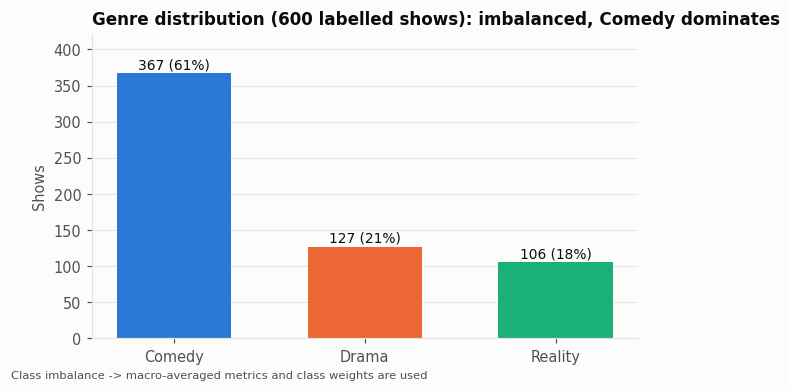

In [5]:
eda.plot_class_distribution(lab);

Comedy is 61% of shows, so a model that always says Comedy scores 61% accuracy. The business target (≥ 0.89) is stated on **support-weighted** one-vs-rest metrics; **macro-averaged** metrics, where Drama and Reality count as much as Comedy, are reported alongside.

## 3. Missing values and duplicate columns

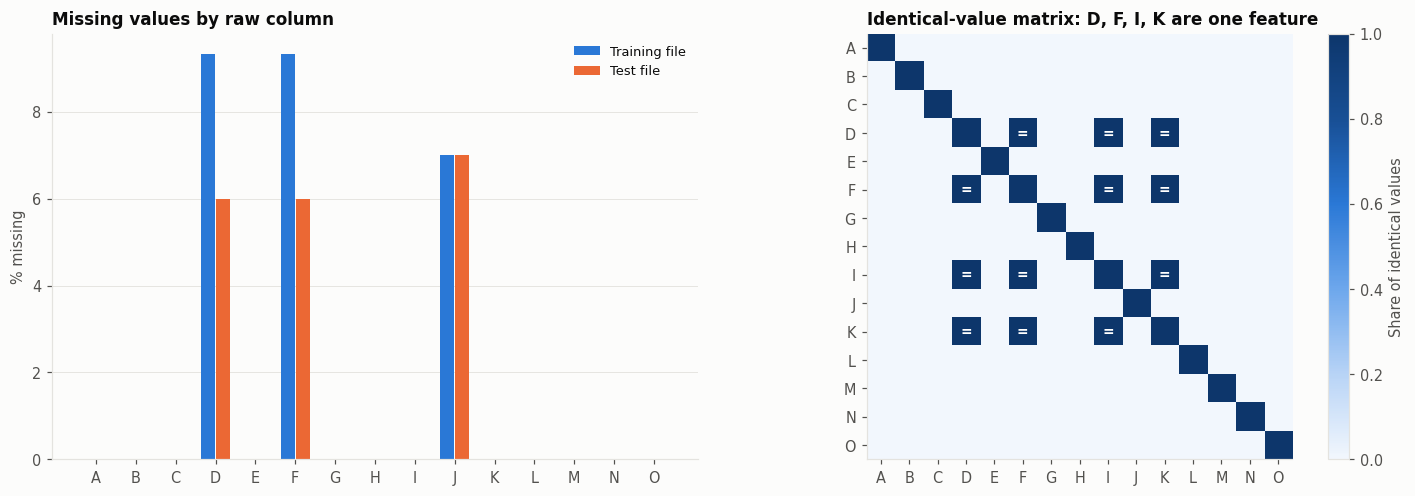

In [6]:
eda.plot_quality(tr, te);

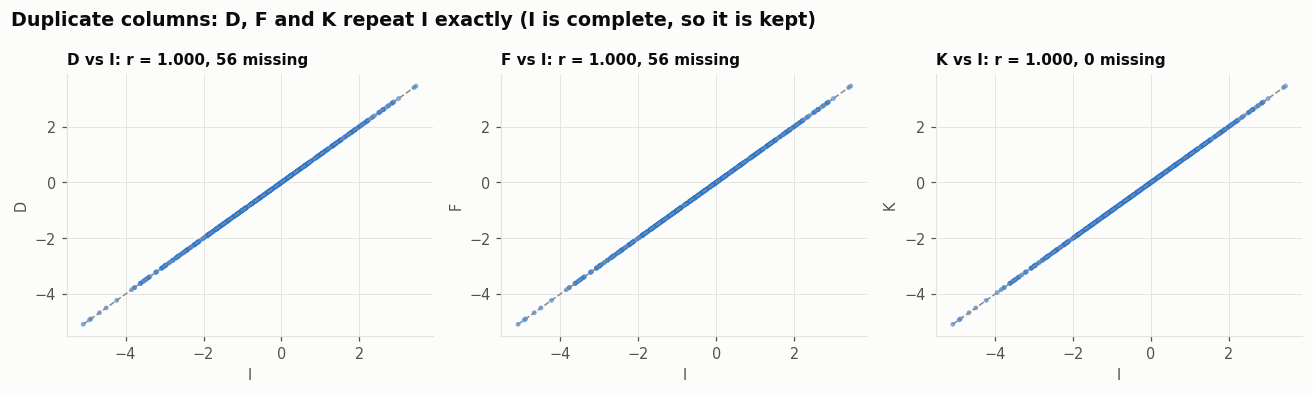

In [7]:
eda.plot_duplicates(tr);

## 4. The unit error in A

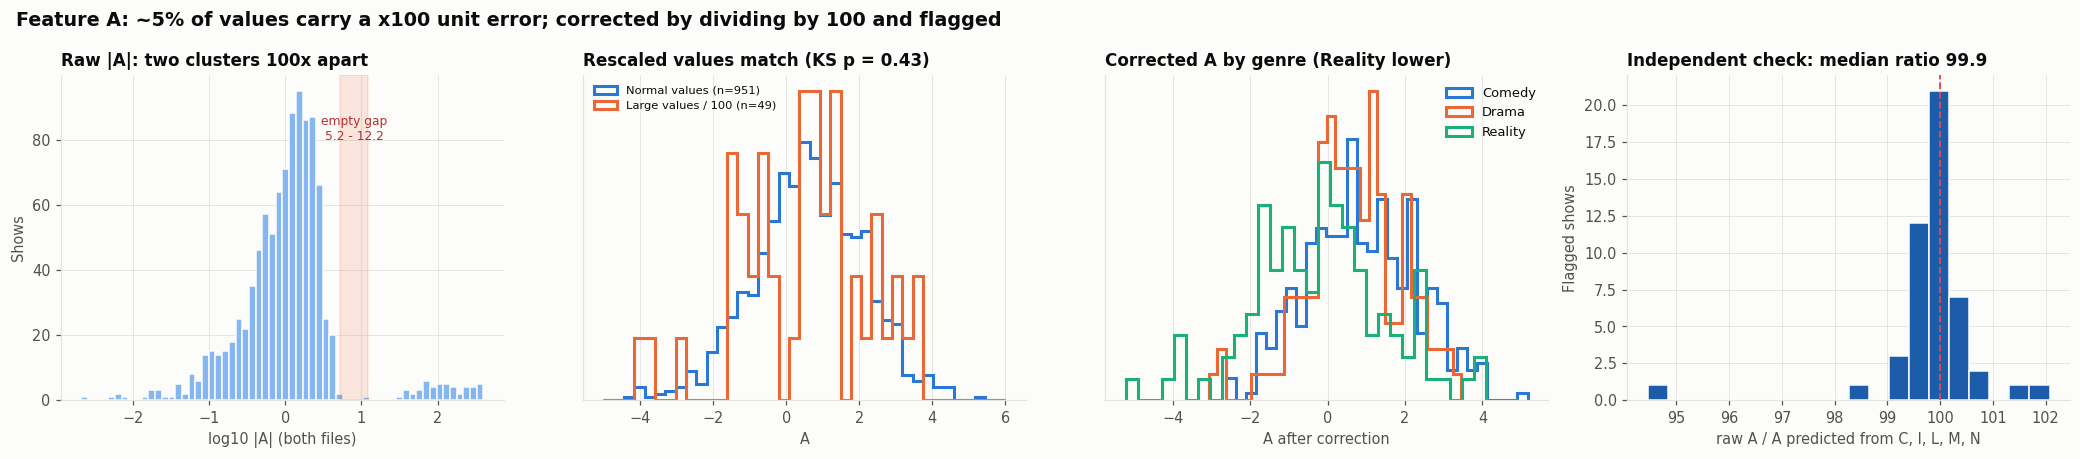

In [8]:
eda.plot_a_unit_error(tr, te, lab);

Three independent pieces of evidence agree: (1) there are no values between 5.2 and 12.2 in absolute value; (2) the large values divided by 100 have the same distribution as the rest; (3) A is ~99.8% predictable from C, I, L, M and N, and raw A / predicted A is ~100 for the flagged shows. The correction is applied, and the flag is kept for traceability (it is **not** used as a model feature).

## 5. Feature distributions by genre

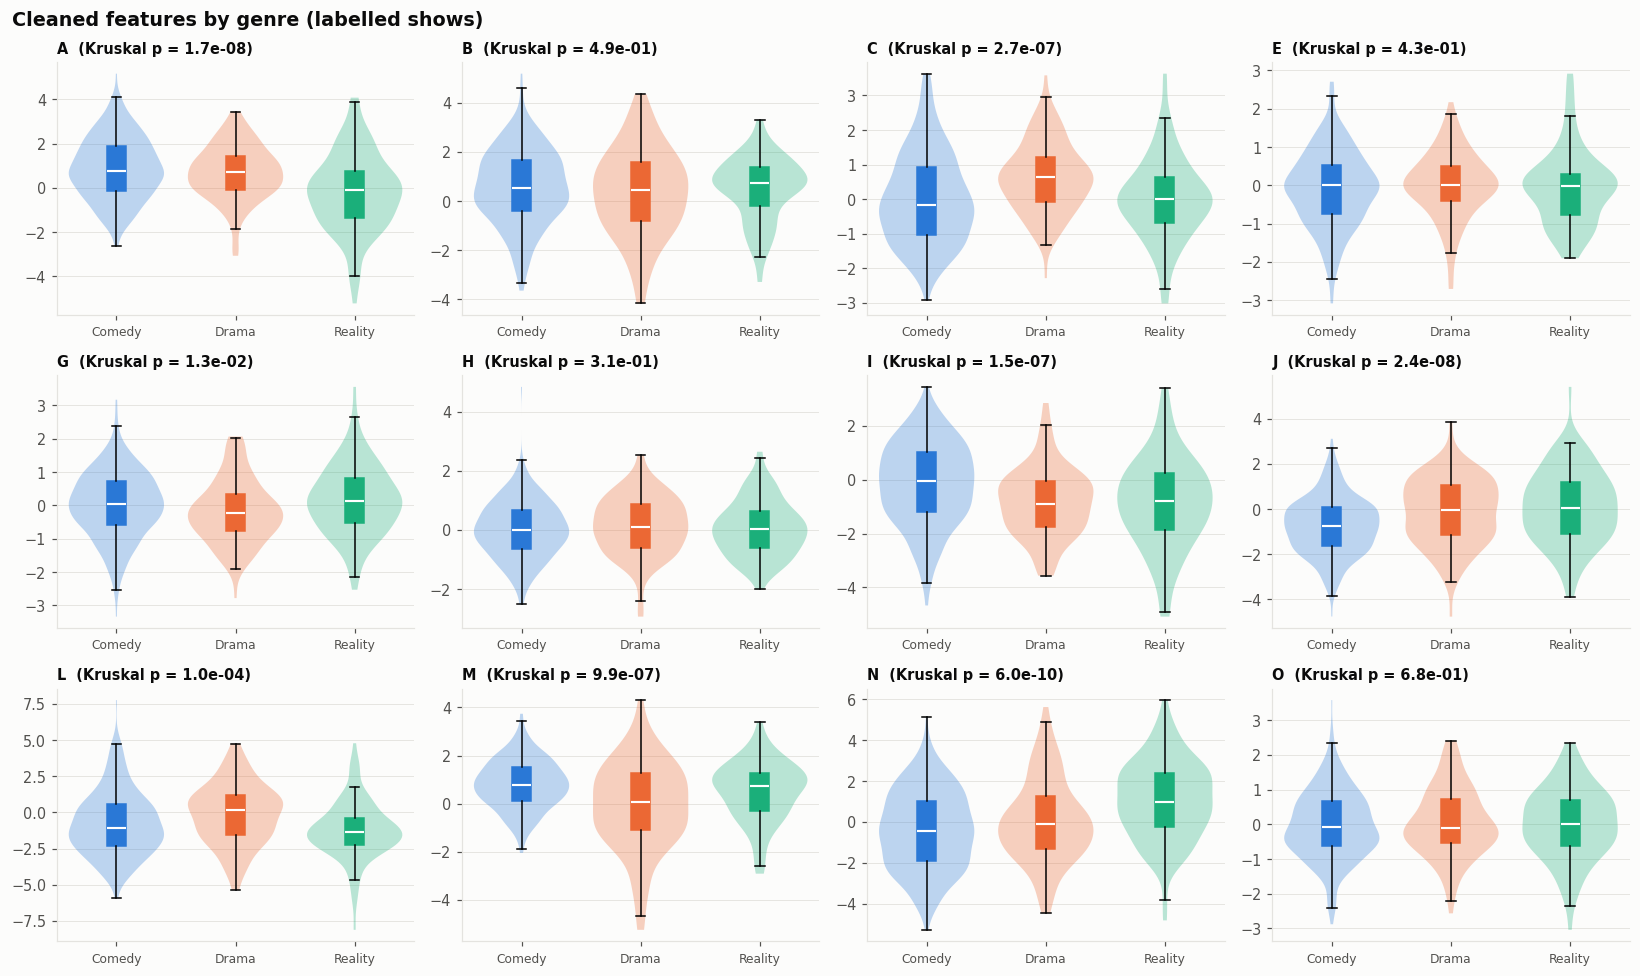

In [9]:
eda.plot_distributions(lab);

In [10]:
R["descriptive"]

genre   Comedy  Drama  Reality
A mean   0.885  0.686   -0.200
  std    1.408  1.228    1.744
B mean   0.553  0.341    0.486
  std    1.520  1.783    1.296
C mean   0.012  0.631   -0.008
  std    1.318  1.014    1.181
E mean  -0.092  0.004   -0.065
  std    0.990  0.875    0.981
G mean   0.015 -0.186    0.154
  std    0.998  0.949    1.046
H mean   0.006  0.138    0.049
  std    0.968  0.998    0.939
I mean  -0.147 -0.832   -0.872
  std    1.536  1.284    1.673
J mean  -0.754 -0.132    0.096
  std    1.271  1.468    1.636
L mean  -0.767 -0.120   -1.234
  std    2.221  2.098    1.980
M mean   0.794 -0.098    0.512
  std    1.029  1.811    1.241
N mean  -0.422  0.055    1.062
  std    1.936  2.015    1.927
O mean  -0.028  0.048    0.017
  std    0.983  0.982    1.023

## 6. Correlation and exact linear dependency

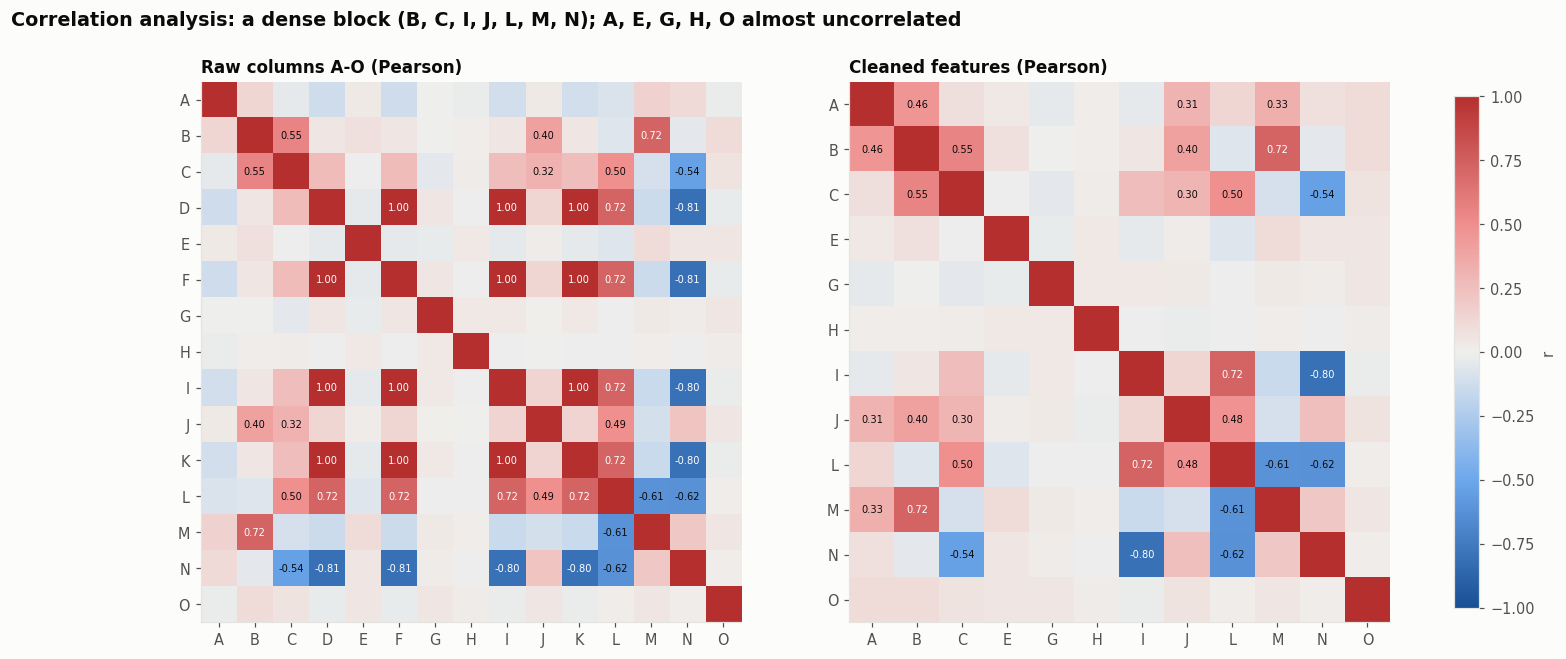

In [11]:
eda.plot_correlation(tr, lab);

B    0.40649
C    0.36687
I    0.64294
L    0.37236
M   -0.23684
N    0.98238
Name: J coefficient, dtype: float64

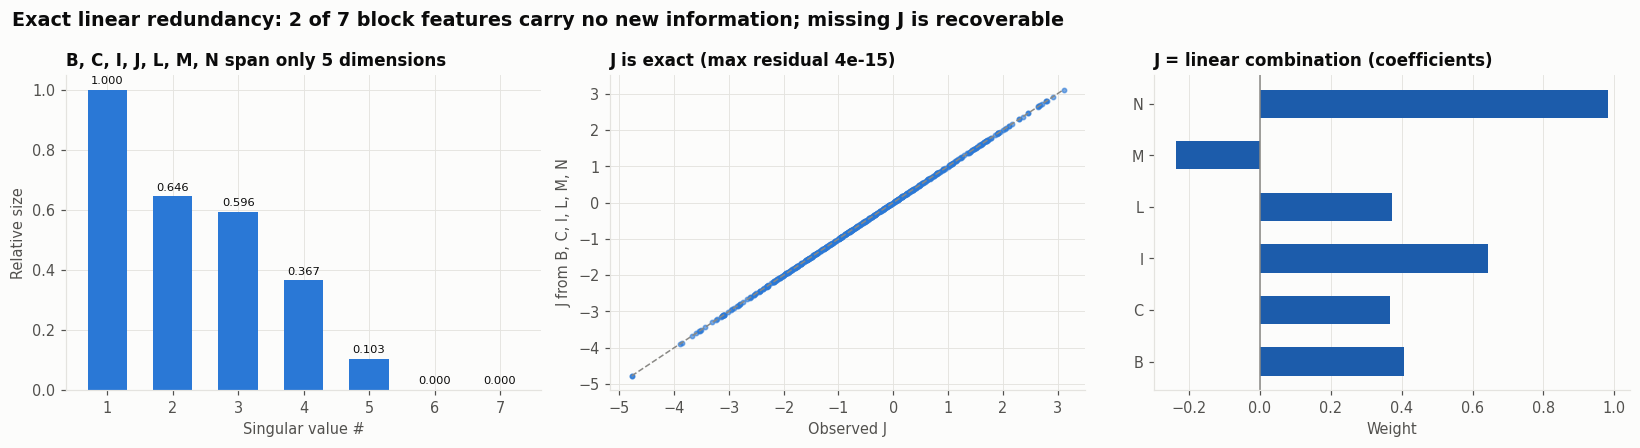

In [12]:
from src.utils import load_json
spec = load_json(cfg.CLEANING_SPEC_FILE)
eda.plot_linear_dependency(lab, spec)
pd.Series(spec["j_coef"], name="J coefficient").round(5)

B, C, I, J, L, M and N span only **5** independent directions, so two of them are exact linear combinations of the others. This is why J can be reconstructed exactly, and it matters for model choice: the genre signal lives in **oblique** combinations of features, which axis-aligned trees approximate poorly. Each genre also looks like a mixture of about two elongated Gaussian clusters in this 5-D space, which is why the final classifiers are built on class-conditional Gaussian mixtures (notebook 03).

## 7. Are the unlabelled shows like the labelled ones?

,feature,ks_stat,p,labelled_mean,unlabelled_mean,q
0,A,0.053,0.491,0.651,0.525,0.673
1,B,0.055,0.451,0.497,0.605,0.673
2,C,0.070,0.184,0.139,0.239,0.442
3,E,0.048,0.617,-0.067,-0.055,0.673
4,G,0.048,0.617,-0.003,0.017,0.673
5,H,0.050,0.574,0.042,-0.007,0.673
6,I,0.079,0.095,-0.420,-0.314,0.380
7,J,0.075,0.130,-0.472,-0.584,0.389
8,L,0.054,0.471,-0.713,-0.766,0.673
9,M,0.041,0.808,0.555,0.654,0.808


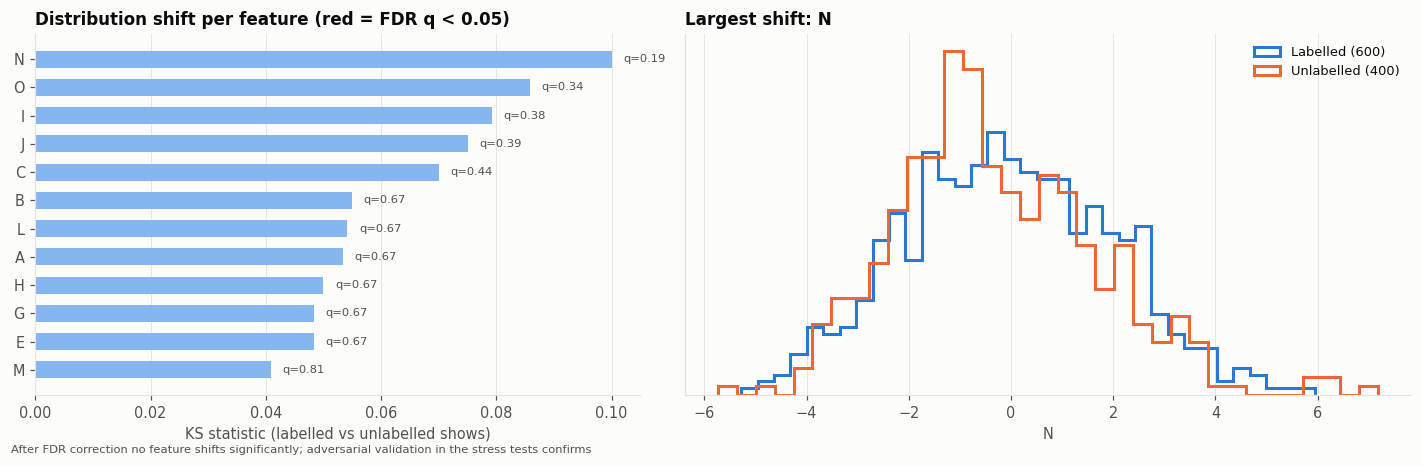

In [13]:
eda.plot_drift(R["drift"], lab, unl)
R["drift"].round(3)

## 8. Univariate separation and 2-D views

,feature,kruskal_H,p,mutual_info,mean_Comedy,mean_Drama,mean_Reality,q
9,M,27.6481,0.0000,0.0722,0.7938,-0.0978,0.5119,0.0000
0,A,35.8392,0.0000,0.0485,0.8854,0.6857,-0.2002,0.0000
1,B,1.4292,0.4894,0.0357,0.5533,0.3412,0.4861,0.5339
2,C,30.2867,0.0000,0.0334,0.0119,0.6309,-0.0080,0.0000
10,N,42.4616,0.0000,0.0237,-0.4225,0.0550,1.0617,0.0000
7,J,35.1276,0.0000,0.0213,-0.7541,-0.1324,0.0963,0.0000
8,L,18.3708,0.0001,0.0187,-0.7674,-0.1198,-1.2335,0.0002
6,I,31.4513,0.0000,0.0124,-0.1472,-0.8324,-0.8723,0.0000
3,E,1.6889,0.4298,0.0073,-0.0925,0.0044,-0.0645,0.5158
11,O,0.7855,0.6752,0.0068,-0.0277,0.0483,0.0166,0.6752


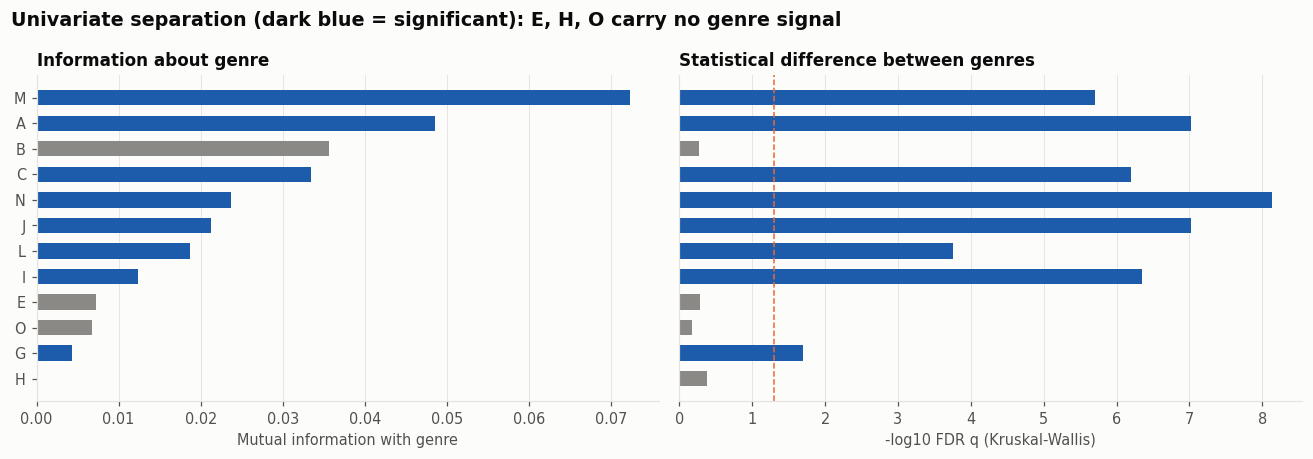

In [14]:
eda.plot_separation(R["separation"])
R["separation"].round(4)

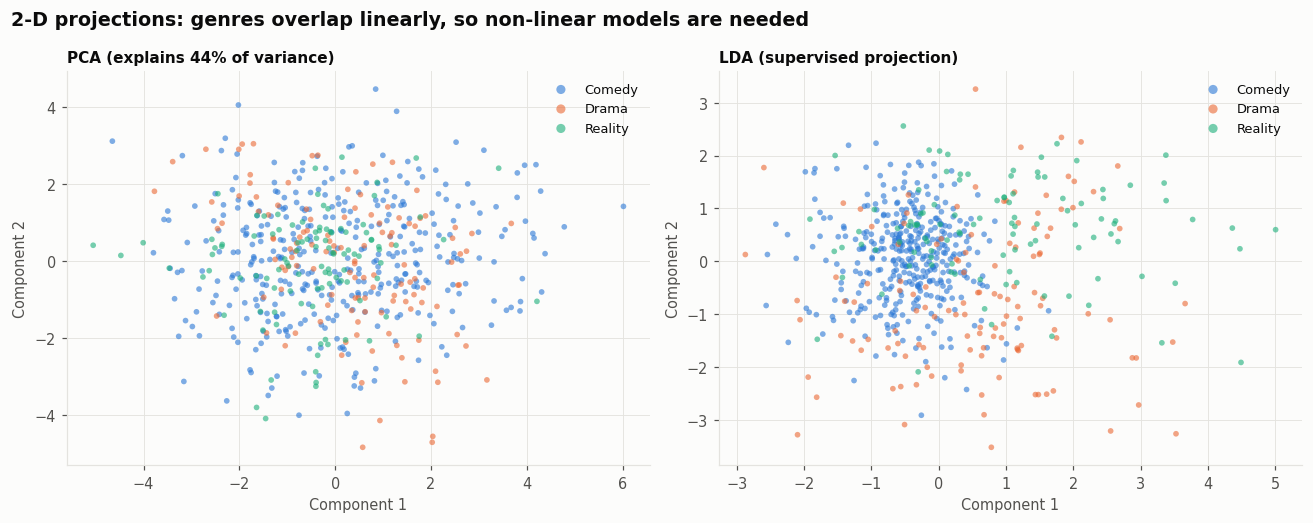

In [15]:
eda.plot_projection(lab);

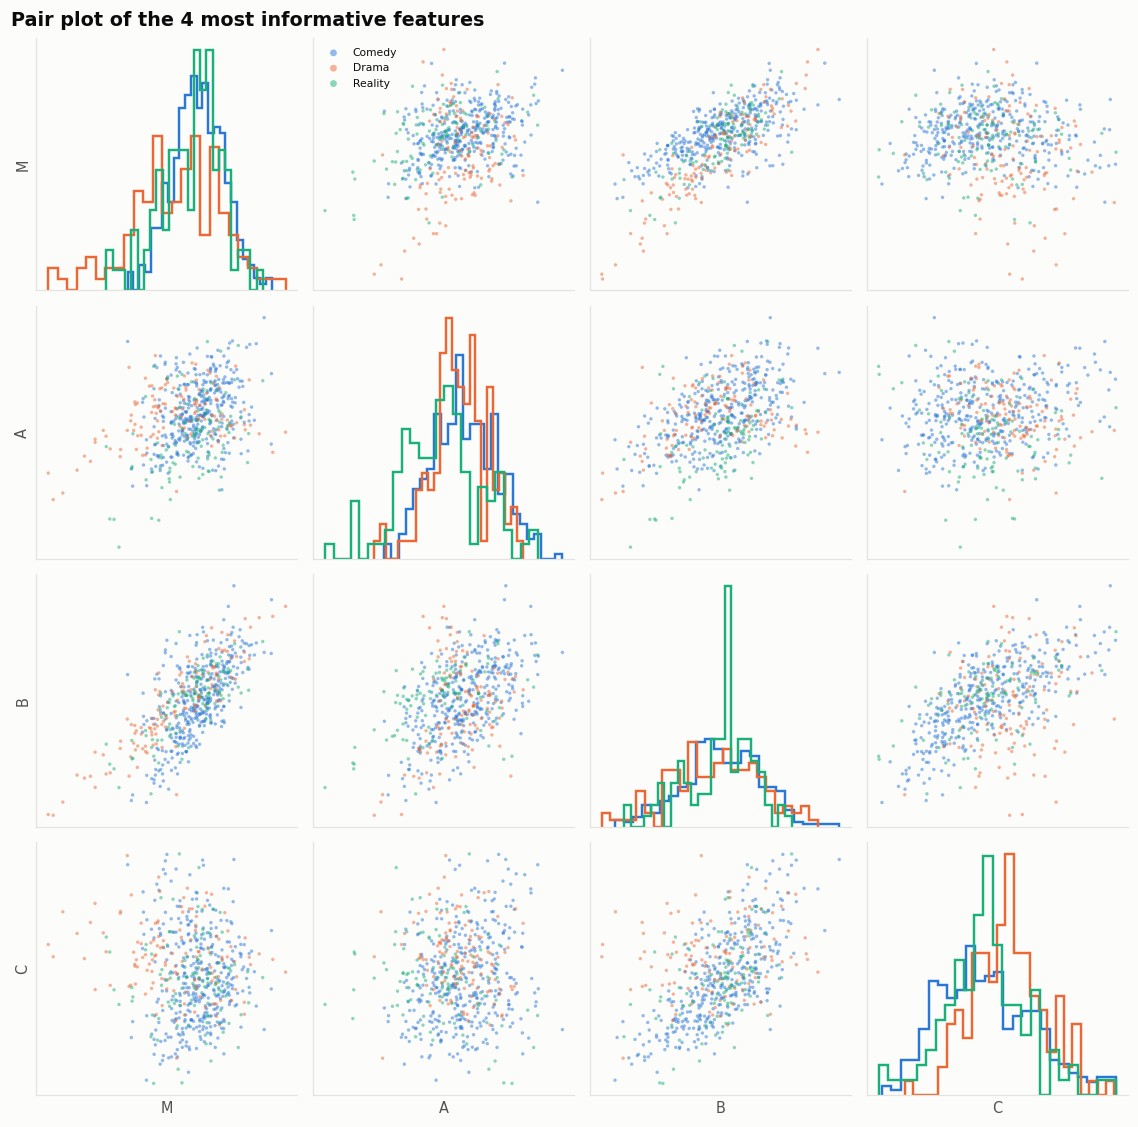

In [16]:
eda.plot_pairs(lab, R["separation"].feature.head(4).tolist());

**Summary**

* Three cleaning rules (duplicate columns, A unit error, J reconstruction) leave **no missing values** and no impossible values.
* No feature drifts between the labelled and unlabelled shows (all FDR q > 0.05), so models trained on the 600 can be applied to the 400.
* The genres overlap heavily in every 2-D view. Expect a hard problem, especially for Reality.